# Lego-Returns -- do retired Lego sets beat the stock market?
### "The toy of smart investors", tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

You will have seen the headline: *retired LEGO sets have returned more than gold, stocks, and bonds.* It comes from a real academic paper (Dobrynskaya & Kishilova, 2022) that found ~10%/yr on the secondary market with almost zero correlation to equities. This notebook asks the only questions that matter for an investor: **after fees, does a basket of retired sets actually beat a plain S&P 500 fund -- and could you realistically capture it?**

> **This is the plain-language layer.** Want the Newey-West t-stat on excess return, the CAPM beta, and the cost model? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from lego_returns import data, strategy as st

def _have_cache():
    try:
        data.fetch_market_annual()
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("S&P 500 cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=38, year_start=1987, year_end=2024,
    lego_cagr=8.3, lego_net_cagr=5.9, market_cagr=8.76,
    lego_mean=8.33, market_mean=10.16,
    mean_excess_gross=-1.83, mean_excess_net=-4.23,
    hac_t_gross=-0.668, hac_t_net=-1.544,
    beta=0.011, alpha=8.22, corr=0.067,
    lego_win_years=16, lego_win_rate=42.1, sign_test_p=0.872,
    one_way_cost=12, holding_years=5, div_yield=2.0,
)


S&P 500 cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the curated Lego index beat the S&P (price-only)? | **No, narrowly.** Lego **8.3%/yr** vs S&P **8.8%/yr** gross -- and the S&P also pays ~2%/yr in dividends the Lego basket cannot. |
| After resale fees? | **Clearly no.** Net of a one-way ~12% marketplace fee, Lego drops to **~5.9%/yr** -- a **-4.2pp/yr** shortfall vs the market. |
| Is the outperformance statistically real? | **No.** Mean excess return is **negative**; Newey-West t = **-0.67** gross, **-1.54** net. |
| Is the 'great diversifier' claim true? | **Partly.** Beta to the market is **~0.01** (genuinely uncorrelated) -- but a low-beta asset that trails the market is not a free lunch. |

> Lego is a real, fun, low-correlation collectible. It is **not** a stock-beating investment once you pay to sell it -- and the published returns are upper bounds.

## 1 - The claim

> *"Retired LEGO sets are a high-return, low-risk alternative investment: on the secondary market they have appreciated ~10%/yr, beating large stocks, bonds, gold and many art categories, with almost no correlation to financial markets."*

This traces to Dobrynskaya & Kishilova (2022), *Research in International Business and Finance*. It is a genuine, careful paper -- but the press telescoped it into "LEGO beats the S&P 500", and quietly dropped the fees, the storage, the illiquidity, and the selection bias.

## 2 - So what?

If true, it would be remarkable: an asset uncorrelated with equities that *also* beats them is the holy grail of portfolio construction -- you would add it for the diversification and keep it for the return. The interesting question is which half of the claim survives contact with a fee schedule. Low correlation? Probably. Market-beating net return for a real buyer? That is what we test.

## 3 - How would we even know?

Three traps to avoid:

1. **The wrong benchmark.** A collectible pays no dividend, so it must be compared to the **price-only** S&P, not total return. We do that -- and still note the ~2%/yr dividend the equity holder pockets on top.
2. **Gross vs net.** Index returns are *paper* returns. Realising them means selling through eBay/BrickLink and paying ~12-15%. A buy-and-hold collector eats that once; we amortise it over the holding period and report both.
3. **Survivorship & selection bias.** A secondary-market index tracks sets that *kept trading*. Flops and liquidations drop out, biasing the index up. Published Lego returns are therefore **upper bounds** -- named on the Signal axis.

We test on a curated annual Lego index (1987-2024, base 100, hardcoded in `data.py`) against S&P 500 calendar-year price returns from the repo cache.

## 4 - The teardown -- let's actually look

**First, the two growth paths.** A dollar in the Lego basket vs a dollar in the S&P (price-only), 1987-2024.

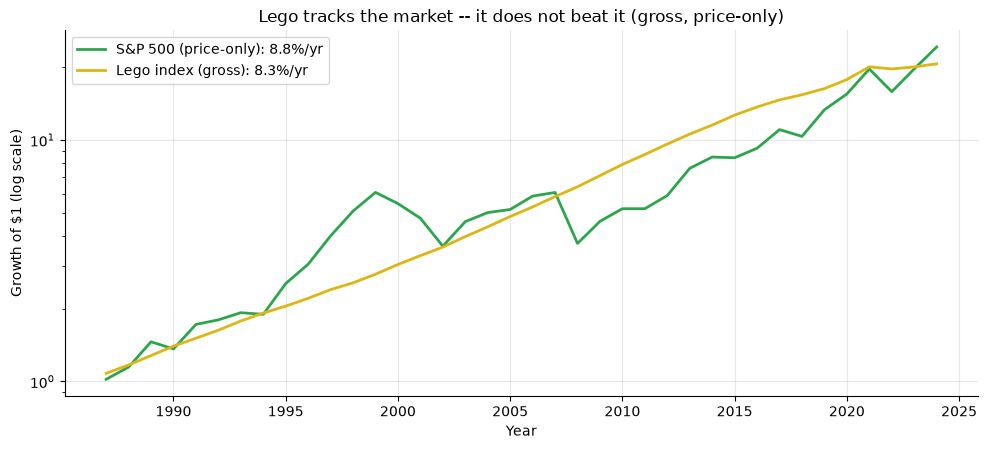

Lego gross CAGR: 8.30%  |  S&P price-only CAGR: 8.76%


In [2]:
if HAVE_REAL:
    df = data.fetch_market_annual()
    yrs = df['year'].values
    lego_cum = (1+df['lego_return']).cumprod().values
    mkt_cum = (1+df['market_return']).cumprod().values
    lego_cagr = float((1+df['lego_return']).prod()**(1/len(df))-1)
    mkt_cagr = float((1+df['market_return']).prod()**(1/len(df))-1)
else:
    rng = np.random.default_rng(273)
    yrs = np.arange(R['year_start'], R['year_end']+1)
    lr = rng.normal(R['lego_mean']/100, 0.09, R['n'])
    mr = rng.normal(R['market_mean']/100, 0.16, R['n'])
    lego_cum = (1+lr).cumprod(); mkt_cum = (1+mr).cumprod()
    lego_cagr = R['lego_cagr']/100; mkt_cagr = R['market_cagr']/100

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(yrs, mkt_cum, lw=2, c=GREEN, label=f'S&P 500 (price-only): {mkt_cagr:.1%}/yr')
ax.plot(yrs, lego_cum, lw=2, c=AMBER, label=f'Lego index (gross): {lego_cagr:.1%}/yr')
ax.set_yscale('log'); ax.set_xlabel('Year')
ax.set_ylabel('Growth of $1 (log scale)')
ax.set_title('Lego tracks the market -- it does not beat it (gross, price-only)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Lego gross CAGR: {lego_cagr:.2%}  |  S&P price-only CAGR: {mkt_cagr:.2%}')

On the gross, price-only comparison the two paths are neck-and-neck -- the Lego basket grows at **8.3%/yr** against the S&P's **8.8%/yr**. And remember: the S&P holder *also* collected ~2%/yr in dividends the Lego owner never sees.

**Now charge the toll.** What happens once you pay to sell?

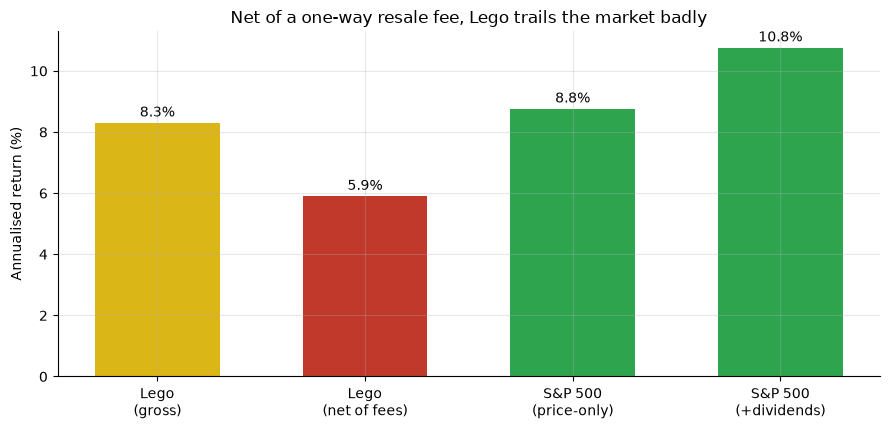

Lego net CAGR (12% fee over 5yr hold): 5.90%
Shortfall vs S&P total return: -4.9pp/yr


In [3]:
if HAVE_REAL:
    net = st.net_lego_return(df['lego_return'].values, one_way_cost=0.12, holding_years=5.0)
    lego_net_cagr = float(np.prod(1+net)**(1/len(net))-1)
else:
    lego_net_cagr = R['lego_net_cagr']/100

bars = ['Lego\n(gross)', 'Lego\n(net of fees)', 'S&P 500\n(price-only)',
        'S&P 500\n(+dividends)']
vals = [lego_cagr*100, lego_net_cagr*100, mkt_cagr*100, mkt_cagr*100 + R['div_yield']]
cols = [AMBER, RED, GREEN, GREEN]
fig, ax = plt.subplots(figsize=(9, 4.4))
b = ax.bar(bars, vals, color=cols, width=0.6)
ax.set_ylabel('Annualised return (%)')
ax.set_title('Net of a one-way resale fee, Lego trails the market badly')
for bar, v in zip(b, vals):
    ax.annotate(f'{v:.1f}%', (bar.get_x()+bar.get_width()/2, v+0.1),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Lego net CAGR (12% fee over 5yr hold): {lego_net_cagr:.2%}')
print(f'Shortfall vs S&P total return: {(lego_net_cagr-(mkt_cagr+R["div_yield"]/100))*100:+.1f}pp/yr')

Amortising a single 12% marketplace fee over a five-year hold knocks the Lego return down to **~5.9%/yr**. Against the S&P's ~10.8%/yr total return, that is a **~5pp/yr** gap -- the difference between doubling your money and quintupling it over 20 years.

**The one true part of the claim: it really is uncorrelated.**

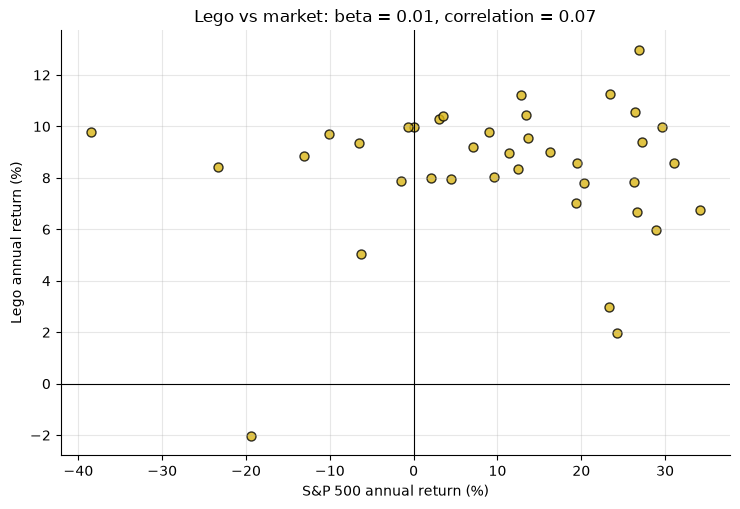

Beta to S&P: 0.011  |  correlation: 0.067
Genuinely uncorrelated -- but a low-beta asset that trails is no free lunch.


In [4]:
if HAVE_REAL:
    b = st.beta_to_market(df['lego_return'].values, df['market_return'].values)
    beta, corr = b['beta'], b['corr']
    lr_s, mr_s = df['lego_return'].values*100, df['market_return'].values*100
else:
    beta, corr = R['beta'], R['corr']
    rng2 = np.random.default_rng(7)
    mr_s = rng2.normal(R['market_mean'], 16, R['n'])
    lr_s = R['lego_mean'] + beta*(mr_s-R['market_mean']) + rng2.normal(0, 9, R['n'])

fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.scatter(mr_s, lr_s, c=AMBER, s=42, edgecolor='k', alpha=0.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('S&P 500 annual return (%)'); ax.set_ylabel('Lego annual return (%)')
ax.set_title(f'Lego vs market: beta = {beta:.2f}, correlation = {corr:.2f}')
plt.tight_layout(); plt.show()
print(f'Beta to S&P: {beta:.3f}  |  correlation: {corr:.3f}')
print('Genuinely uncorrelated -- but a low-beta asset that trails is no free lunch.')

The diversification claim holds up: beta is **~0.01**, correlation **~0.07**. Lego does not move with the market. But uncorrelated-*and*-lower-returning is not the holy grail the headlines promised -- it is just a different, lower-return bet.

## 5 - The verdict

- **Signal -- None.** Gross Lego (8.3%/yr) slightly trails the price-only S&P (8.8%/yr); mean excess return is negative, Newey-West t = -0.67 gross, -1.54 net. There is no statistically positive equity-beating premium, and the index is survivorship-/selection-biased upward.
- **Tradability -- Mirage.** Even if the paper return were positive, you cannot capture it: ~12-15% one-way fees, storage, insurance, single-item illiquidity, and a buyer who pays full RRP. Net of frictions Lego trails a cheap index fund.
- **Busted (as an investment).** The fun, the nostalgia, and the genuine low correlation are real. The "beats the stock market" headline is not, once you account for dividends and the cost of selling.

## 6 - Could you actually trade it?

The 'strategy' is: buy sets at retail, store them for years, then resell. The frictions are brutal and unavoidable:

- **Marketplace fees** ~12-15% one-way (eBay/BrickLink + payment processing).
- **Storage**: a market-beating basket is bulky; mint condition requires climate control and space.
- **Illiquidity**: each set is a single, non-fungible item; selling 100 sets is 100 listings, photos, and shipments.
- **Selection risk**: the index averages winners *and* the flops the index quietly dropped; your shelf may hold the flops.

Against a one-click, ~0.03% expense-ratio S&P fund that pays dividends, the operational gap is decisive.

## 7 - Going further

- **The positive control:** the companion notebook plants a real Lego premium in a synthetic tape and shows the Newey-West machinery detects it -- so a flat result on the real tape is a statement about Lego, not the method.
- **Same family:** other 'alternative asset beats stocks' folklore -- wine, watches, trading cards, NFTs -- shares the gross-vs-net and survivorship traps.

*Think your curated set list beats the market net of fees? Fork this, drop in your own index, and show a positive Newey-West t on net excess return. That's the bar.*